In [63]:
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt
from pandas import DataFrame

from caveat.evaluate.describe import transitions
from caveat.evaluate.describe.frequency import frequency_plots
from caveat.evaluate.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from caveat.evaluate.describe.transitions import sequence_prob_plot

In [64]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_paths = {
    "Disc RNN": Path("../logs/TRB/discrim"),
    # "C_Discrim": Path("../logs/TRB/c_discrim"),
    "VAE": Path("../logs/TRB/vae"),
    "JVAE": Path("../logs/TRB/jvae"),
    # "CVAE": Path("../logs/TRB/cvae"),
}

# find data
target_schedules = pd.read_csv("../tmp/nts_home_schedules.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv("../tmp/nts_home_attributes_groups.csv")


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


next(find_nth(Path("../logs/paper_d_rnn")))

('DiscLSTM5', PosixPath('../logs/paper_d_rnn/DiscLSTM5/version_1'))

In [65]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/TRB/discrim/discrim_nrun0/version_0
Failed to find attributes at ../logs/TRB/vae/vae_nrun0/version_0
Loading synthetic labels from ../logs/TRB/jvae/jvae_nrun0/version_0


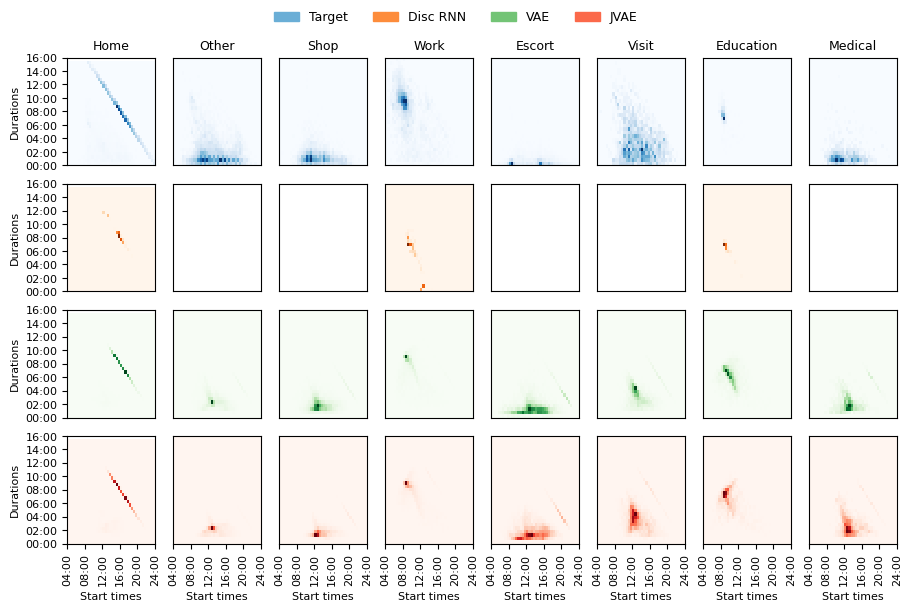

In [66]:
fig = joint_time_distributions_plot(
    target_schedules,
    schedules,
    figsize=(9, 6),
    observed_title="Target",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)

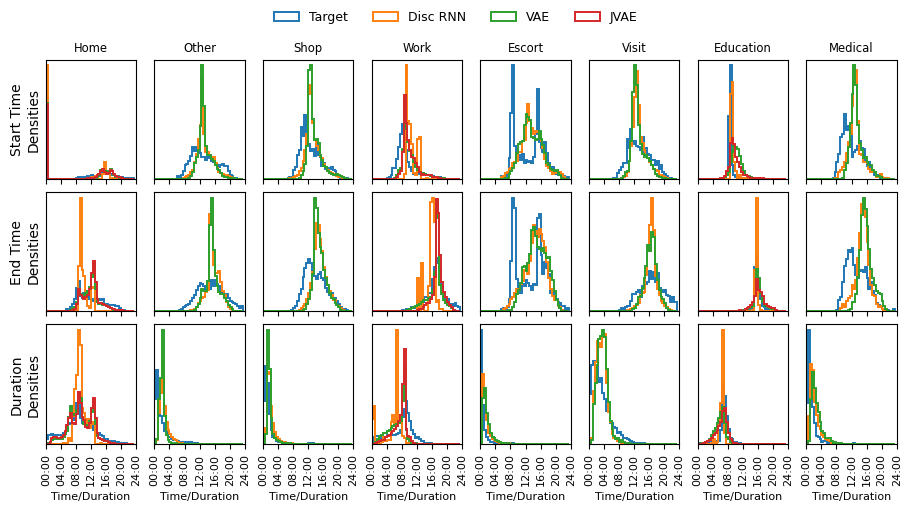

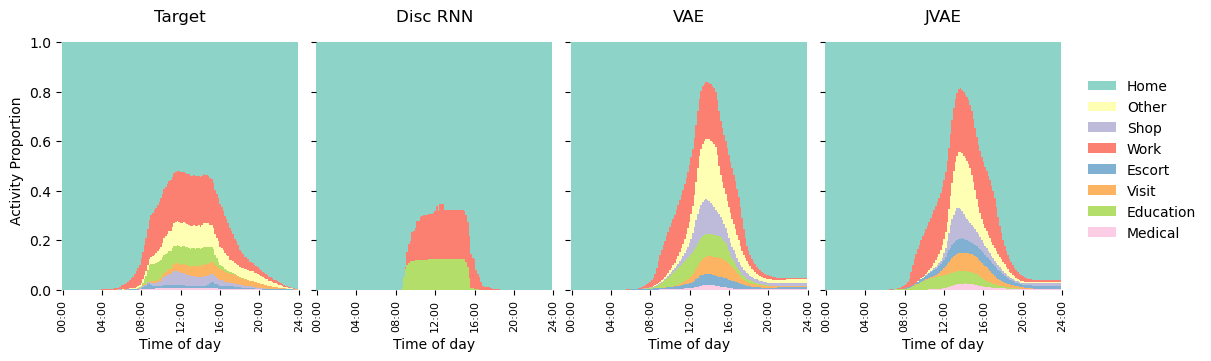

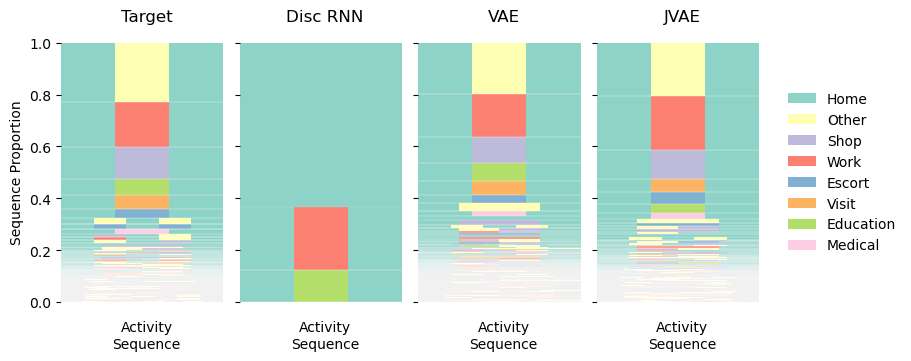

In [67]:
fig = times_distributions_plot(
    target_schedules, schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    schedules,
    color=cmap,
    figsize=(12, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    target_schedules,
    schedules,
    cmap=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)

In [68]:
import random

from pam.core import Household, Person
from pam.plot.plans import plot_household

from caveat.data.utils import trace_to_pam


def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):

    cmap = {
        "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
        "other": (1.0, 1.0, 0.7019607843137254),
        "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
        "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
        "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
        "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
        "education": (
            0.7019607843137254,
            0.8705882352941177,
            0.4117647058823529,
        ),
        "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
        "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
    }
    cmap = {n.title(): c for n, c in cmap.items()}

    hh = Household("")

    pids = schedules.pid
    selected = random.sample(list(pids), 5)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

/tmp/ipykernel_953635/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_953635/1738895634.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_953635/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping 

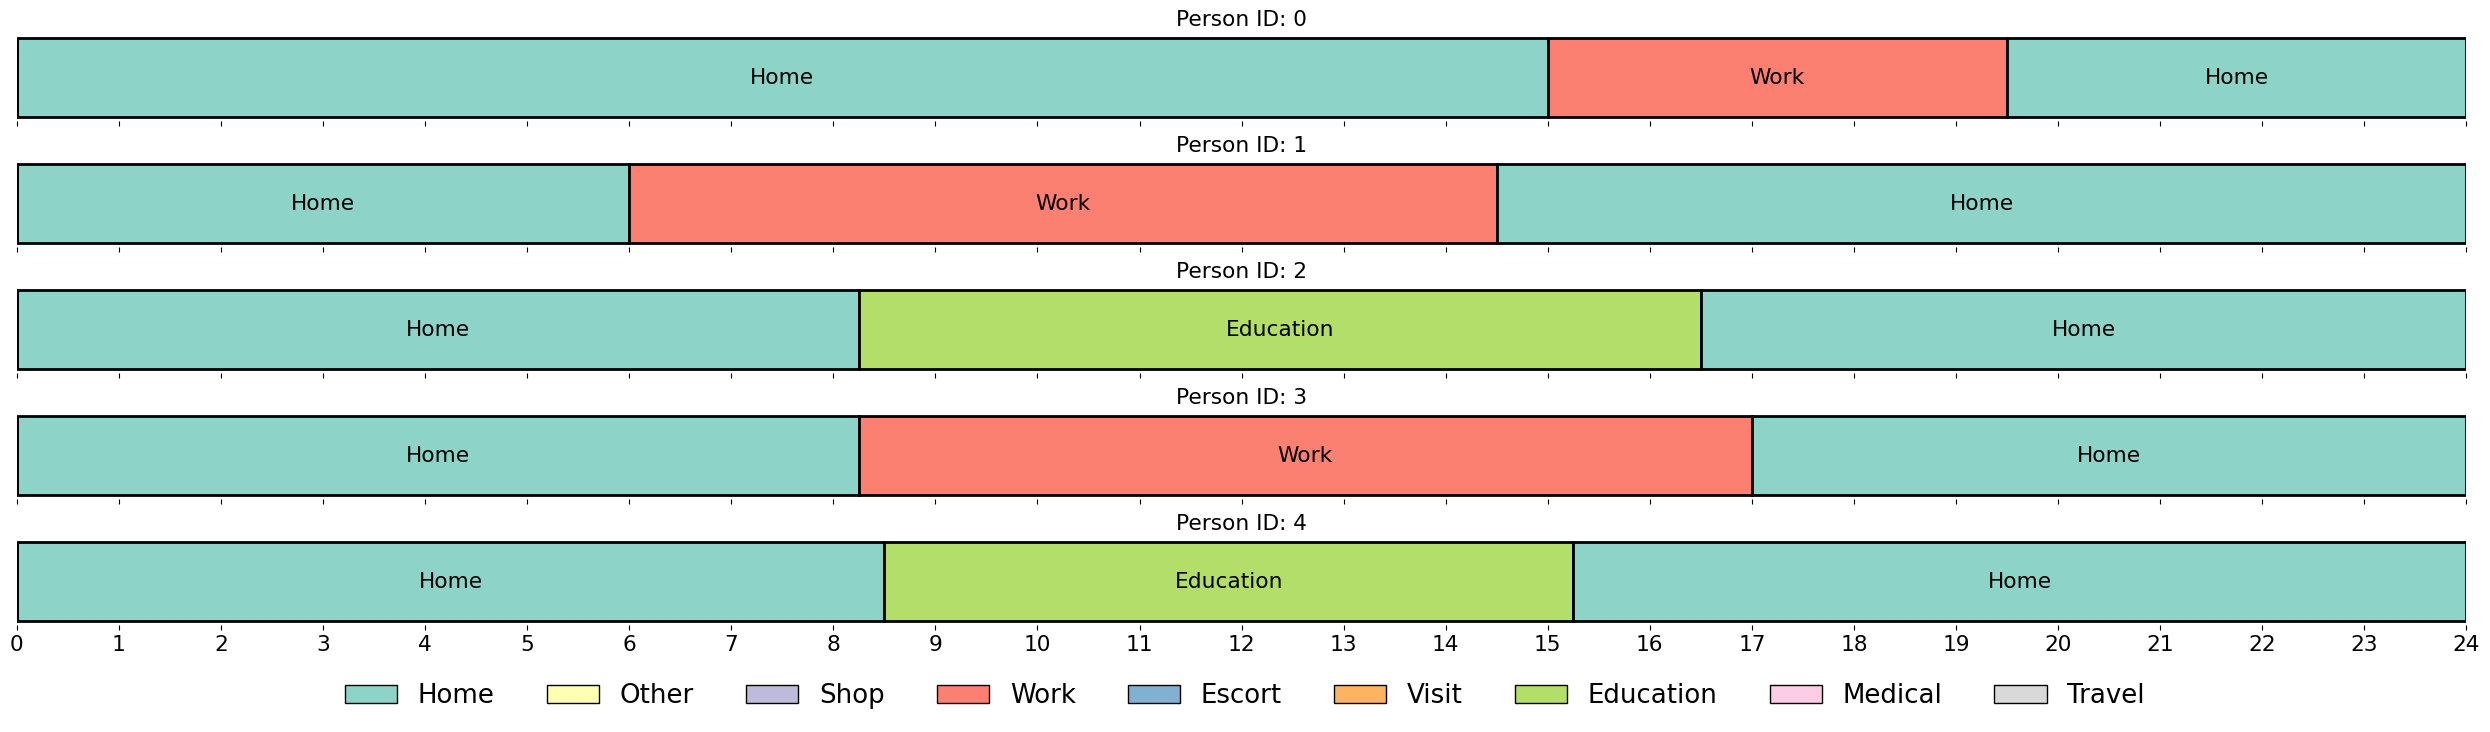

In [69]:
plot_schedules(target_schedules)

/tmp/ipykernel_953635/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_953635/1738895634.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_953635/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping 

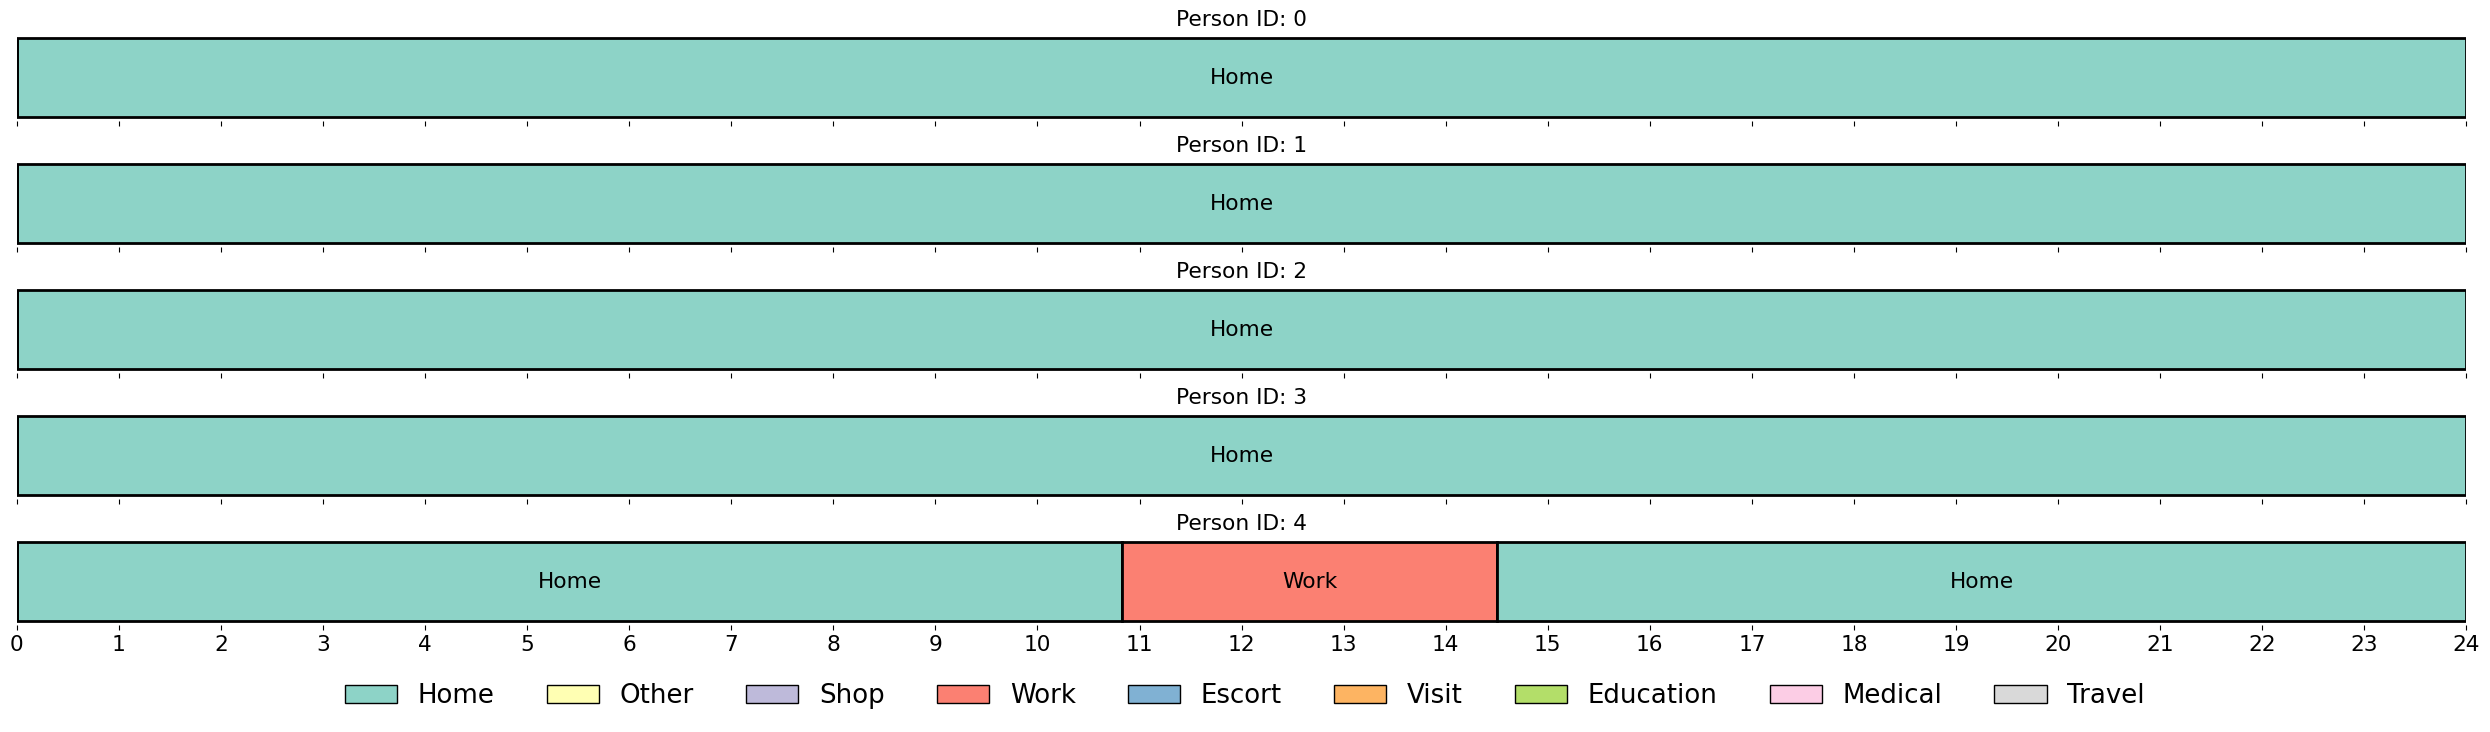

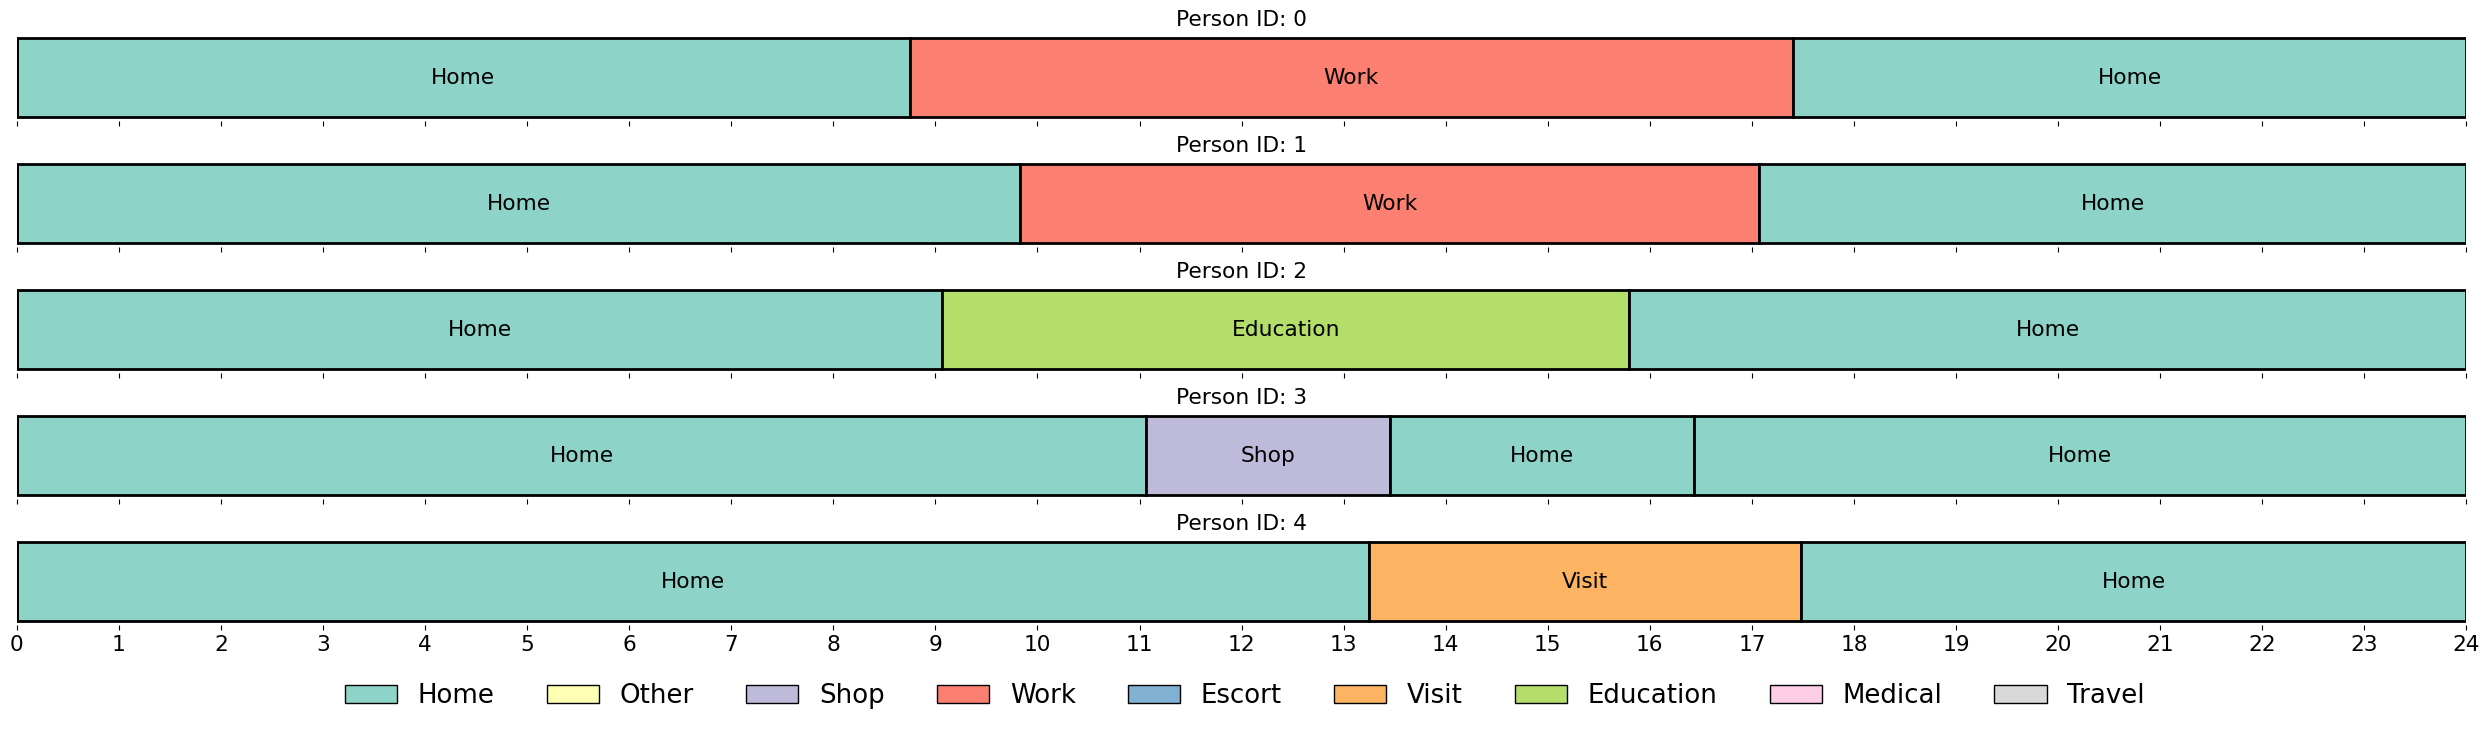

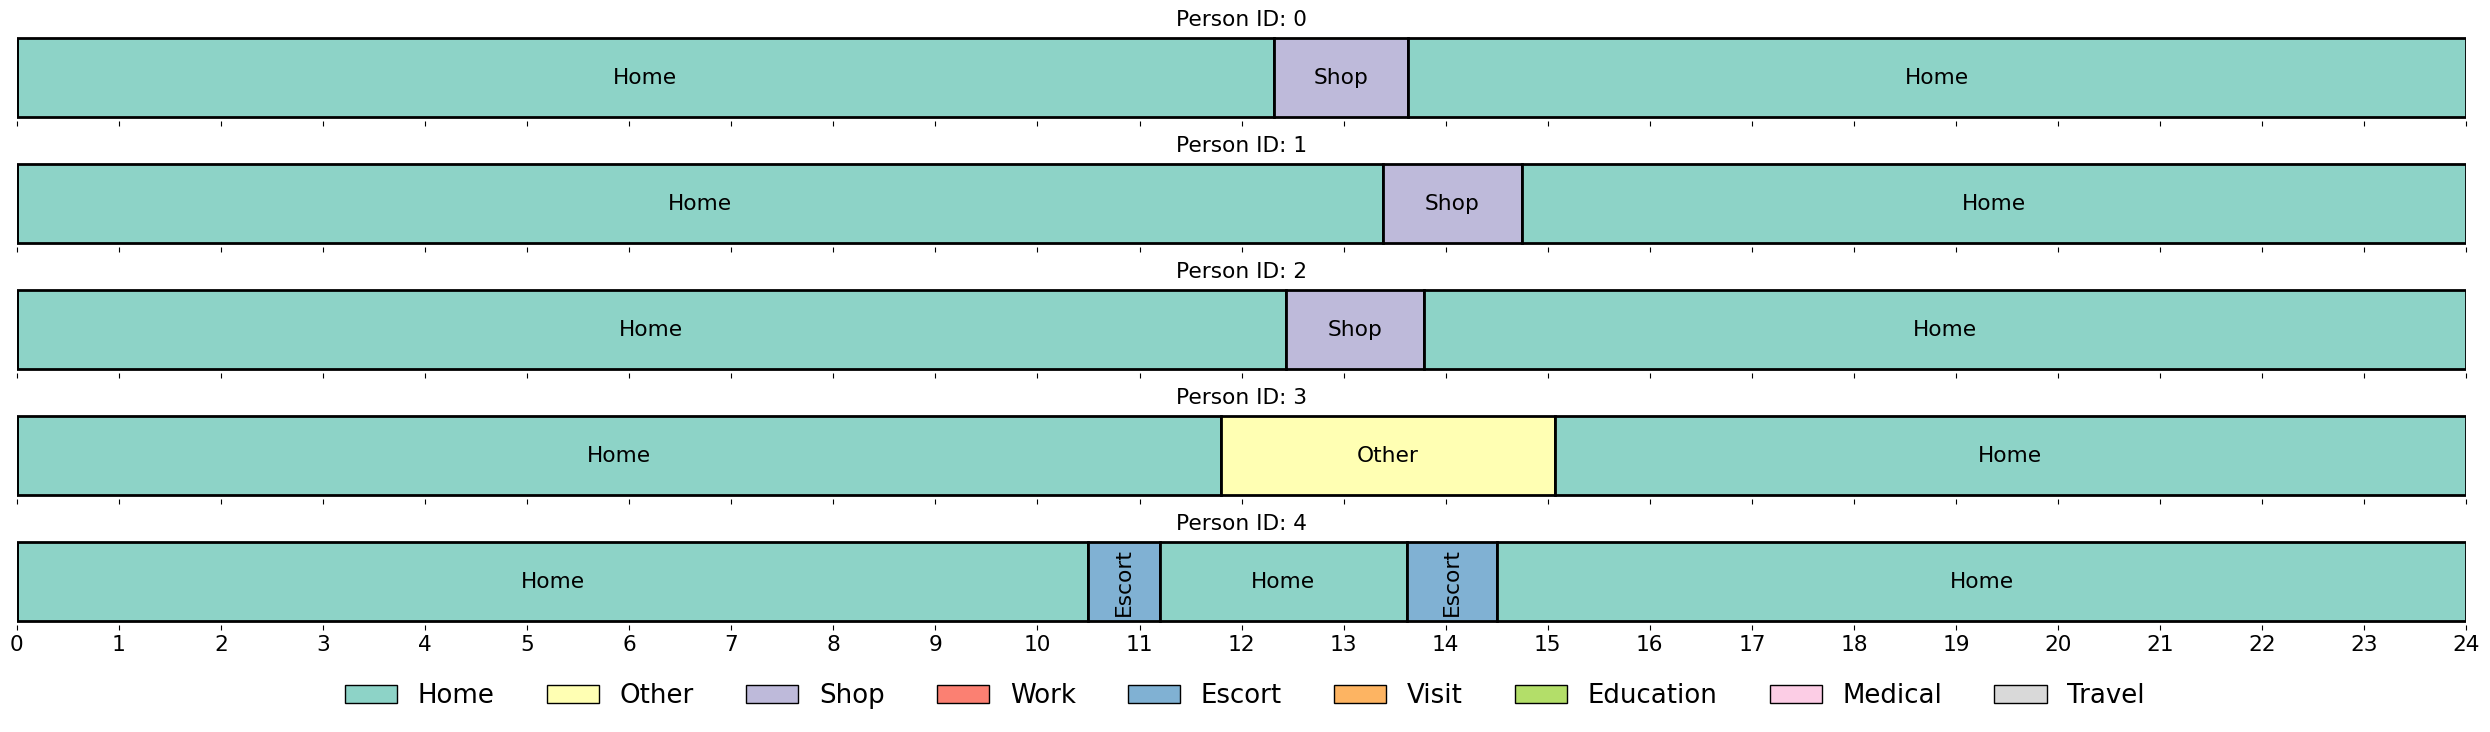

In [70]:
for n, p in batch_paths.items():
    examples = pd.read_csv(next(find_nth(p))[1] / "synthetic_schedules.csv")
    plot_schedules(examples)

In [71]:
def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k.title(): schedules.loc[schedules.pid.isin(list(v.pid))]
        for k, v in splits
    }

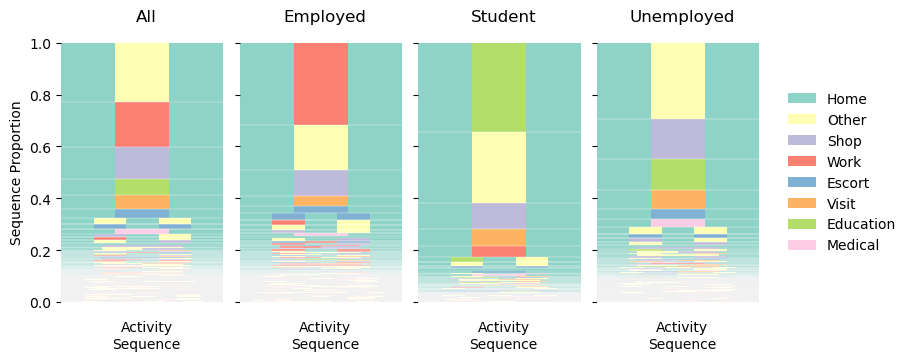

In [72]:
splits = split_on(target_schedules, target_attributes)
fig = transitions.sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

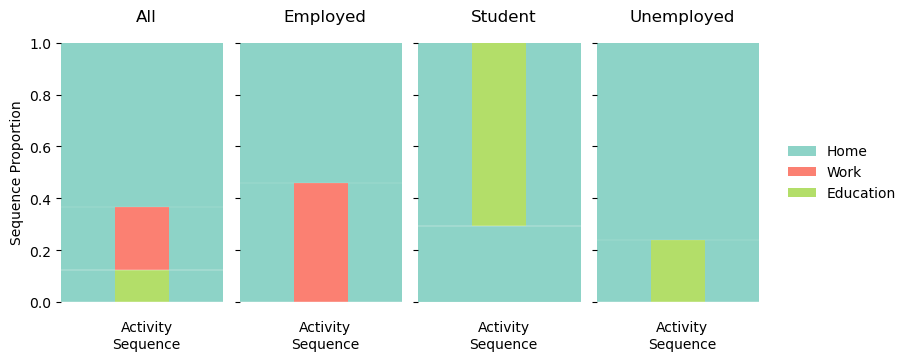

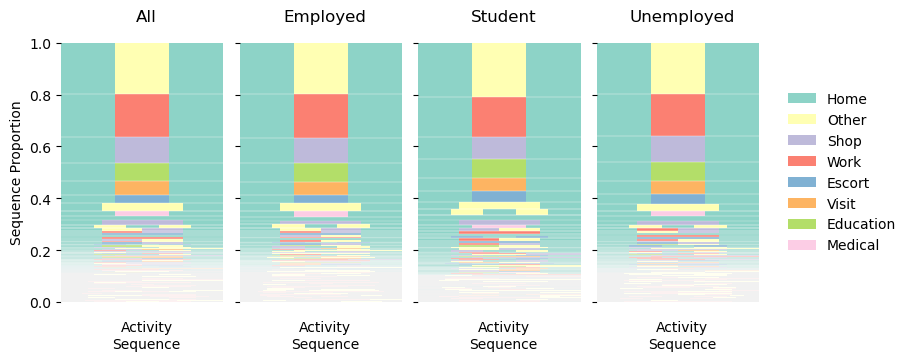

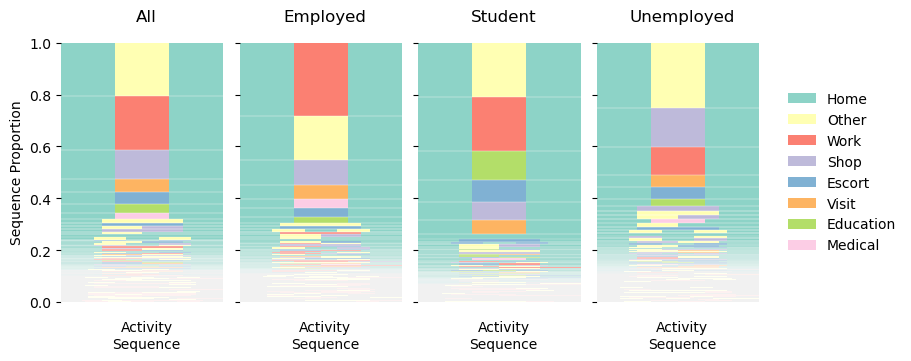

In [73]:
for k, scheds in schedules.items():
    splits = split_on(scheds, attributes[k])
    fig = transitions.sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

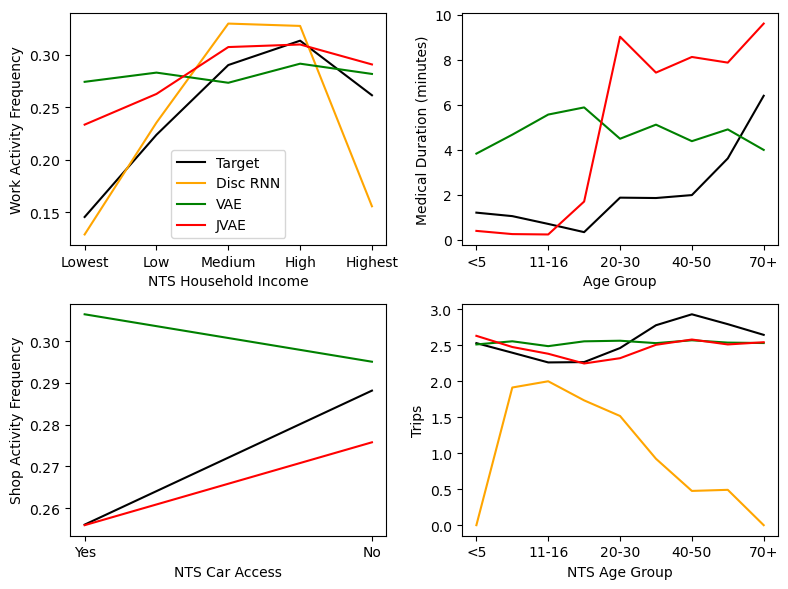

In [ ]:
def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }


def meds(schedules):
    n = schedules.pid.nunique()
    return schedules[schedules.act == "medical"].duration.sum() / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(split.loc[split.act == act]) / n


fig, axs = plt.subplots(2, 2, figsize=(8, 6))

# work

splits = split_on(target_schedules, target_attributes, by="income")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_acts(split)


for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="income")
    for i, split in splits.items():
        data[n][i] = count_acts(split)

df = pd.DataFrame(data)
ax = axs[0][0]
df.plot(ax=ax, color=["black", "orange", "green", "red"])
ax.set_ylabel("Work Activity Frequency")
ax.set_xlabel("NTS Household Income")
ax.set_xticks([1, 2, 3, 4, 5], ["Lowest", "Low", "Medium", "High", "Highest"])

# meds

splits = split_on(target_schedules, target_attributes, by="age_group")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = meds(split)

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="age_group")
    for i, split in splits.items():
        data[n][i] = meds(split)

order = [
    "<5",
    "5-11",
    "11-16",
    "16-20",
    "20-30",
    "30-40",
    "40-50",
    "50-70",
    "70+",
]

df = pd.DataFrame(data)
ax = axs[0][1]
df.loc[order, ["Target", "VAE", "JVAE"]].plot(
    ax=ax, color=["black", "green", "red"]
)
ax.legend().remove()
ax.set_ylabel("Medical Duration (minutes)")
ax.set_xlabel("Age Group")

# shop

splits = split_on(target_schedules, target_attributes, by="car_access")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_acts(split, act="shop")


for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="car_access")
    for i, split in splits.items():
        data[n][i] = count_acts(split, act="shop")

df = pd.DataFrame(data).loc[["yes", "no"], ["Target", "VAE", "JVAE"]]

ax = axs[1][0]

df.plot(ax=ax, color=["black", "green", "red"])
ax.set_ylabel("Shop Activity Frequency")
ax.set_xlabel("NTS Car Access")
ax.legend().remove()
ax.set_xticks([0, 1], ["Yes", "No"])

# trips

splits = split_on(target_schedules, target_attributes, by="age_group")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_trips(split)

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="age_group")
    for i, split in splits.items():
        data[n][i] = count_trips(split)

order = [
    "<5",
    "5-11",
    "11-16",
    "16-20",
    "20-30",
    "30-40",
    "40-50",
    "50-70",
    "70+",
]

df = pd.DataFrame(data)
ax = axs[1][1]
df.loc[order].plot(ax=ax, color=["black", "orange", "green", "red"])
ax.legend().remove()
ax.set_ylabel("Trips")
ax.set_xlabel("NTS Age Group")

fig.tight_layout()

In [75]:
target_attributes.head()

,Unnamed: 0,pid,age,gender,ethnicity,education,license,car_access,work_status,area,income,hh_size,hh_composition,hh_children,hh_cars,hh_bikes,hh_motorcycles,age_group
0,0,0,50,M,white,N,yes,yes,unemployed,urban,1,1,1adult,0,1.0,0,0.0,50-70
1,1,1,50,M,white,N,yes,yes,unemployed,urban,1,1,1adult,0,1.0,0,0.0,50-70
2,2,2,50,M,white,N,yes,yes,unemployed,urban,1,1,1adult,0,1.0,0,0.0,50-70
3,3,3,50,M,white,N,yes,yes,unemployed,urban,1,1,1adult,0,1.0,0,0.0,50-70
4,4,4,50,M,white,N,yes,yes,unemployed,urban,1,1,1adult,0,1.0,0,0.0,50-70


In [76]:
def build_distance_tables(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"domain_distances{suffix}.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "EMD")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    # distances_combined = distances_combined.set_index(
    #     pd.MultiIndex.from_tuples(distances_combined.index)
    # )

    return distances_combined


df = build_distance_tables(batch_paths, suffix="")
print(df[::-1].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrr}
\toprule
 & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  \\
\midrule
aggregate & 0.037 & 0.000 & 0.018 & 0.000 & 0.018 & 0.000 \\
count & 0.000 & 0.000 & 0.000 & 0.000 & 2364.000 & 0.000 \\
creativity & 0.662 & 0.000 & 0.068 & 0.000 & 0.074 & 0.000 \\
participations & 0.696 & 0.001 & 0.084 & 0.000 & 0.083 & 0.000 \\
sample quality & 0.000 & 0.000 & 0.013 & 0.000 & 0.012 & 0.000 \\
timing & 0.284 & 0.000 & 0.059 & 0.000 & 0.060 & 0.000 \\
transitions & 0.034 & 0.000 & 0.007 & 0.000 & 0.007 & 0.000 \\
\bottomrule
\end{tabular}



Disc RNN                     VAE                       JVAE  \
                     EMD           var       EMD           var          EMD   
domain                                                                        
aggregate       0.037235  2.111578e-05  0.018204  1.312122e-06     0.018249   
count           0.000000  0.000000e+00  0.000000  0.000000e+00  2364.000000   
creativity      0.662072  4.474691e-04  0.067705  3.805226e-05     0.073853   
participations  0.696249  5.914686e-04  0.083878  3.720802e-04     0.083256   
sample quality  0.000000  0.000000e+00  0.013266  1.812631e-06     0.011968   
timing          0.283992  3.881879e-04  0.058801  1.731639e-06     0.060291   
transitions     0.033972  1.525426e-07  0.007061  6.241252e-07     0.006906   

                              
                         var  
domain                        
aggregate       1.961841e-06  
count           0.000000e+00  
creativity      9.183283e-05  
participations  2.114183e-04  
sample quality  6.459539e-06  
timing          6.765149e-06  
transitions     5.475949e-07

In [77]:
df = build_distance_tables(batch_paths, suffix="_subs")
print(df[::-1].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrr}
\toprule
 & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  \\
\midrule
aggregate & 0.043 & 0.000 & 0.022 & 0.000 & 0.022 & 0.000 \\
count & 537.273 & 0.000 & 537.273 & 0.000 & 537.273 & 0.000 \\
creativity & 0.546 & 0.000 & 0.020 & 0.000 & 0.023 & 0.000 \\
participations & 0.663 & 0.001 & 0.094 & 0.000 & 0.096 & 0.000 \\
sample quality & 0.000 & 0.000 & 0.013 & 0.000 & 0.012 & 0.000 \\
timing & 0.277 & 0.000 & 0.063 & 0.000 & 0.065 & 0.000 \\
transitions & 0.047 & 0.000 & 0.017 & 0.000 & 0.017 & 0.000 \\
\bottomrule
\end{tabular}



Disc RNN                       VAE                \
                       EMD           var         EMD           var   
domain                                                               
aggregate         0.042978  2.065585e-05    0.021755  1.198153e-06   
count           537.272727  0.000000e+00  537.272727  0.000000e+00   
creativity        0.545784  3.454681e-05    0.019653  2.060771e-06   
participations    0.663449  5.600786e-04    0.094417  1.065421e-04   
sample quality    0.000000  0.000000e+00    0.013128  3.052802e-06   
timing            0.277149  3.817130e-04    0.062591  5.197593e-07   
transitions       0.046874  9.547535e-07    0.016707  5.091604e-07   

                      JVAE                
                       EMD           var  
domain                                    
aggregate         0.022051  1.543978e-06  
count           537.272727  0.000000e+00  
creativity        0.023128  1.570982e-05  
participations    0.096285  7.957049e-05  
sample quality    0.011755  7.142948e-06  
timing            0.064602  5.100494e-06  
transitions       0.016779  7.599610e-07

In [78]:
def build_feature_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "feature_descriptions.csv").set_index(
            ["domain", "feature"]
        )
        distances = pd.read_csv(path / "feature_distances.csv").set_index(
            ["domain", "feature"]
        )
        print(distances.columns)

        columns = set(descriptions.columns)
        columns = list(
            columns - set(["observed", "description", "mean", "std"])
        )
        assert len(columns) == 5

        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )
        # descriptions_combined[(name, "var")] = descriptions[columns].var(axis=1)
        descriptions_combined[(name, "EMD")] = distances[columns].mean(axis=1)

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    descriptions_combined[("Observed", "")] = descriptions["observed"]
    descriptions_combined[("Description", "")] = descriptions["description"]

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return descriptions_combined.loc[index, order]


table = build_feature_description_tables(batch_paths)
table

Index(['observed', 'discrim_nrun0', 'discrim_nrun1', 'discrim_nrun2',
       'discrim_nrun3', 'discrim_nrun4', 'distance'],
      dtype='object')
Index(['observed', 'vae_nrun0', 'vae_nrun1', 'vae_nrun2', 'vae_nrun3',
       'vae_nrun4', 'distance'],
      dtype='object')
Index(['observed', 'jvae_nrun0', 'jvae_nrun1', 'jvae_nrun2', 'jvae_nrun3',
       'jvae_nrun4', 'distance'],
      dtype='object')


Observed  Disc RNN            \
                                                      mean       EMD   
domain         feature                                                 
creativity     diversity                0.549724  0.002536       NaN   
               novelty                  1.000000  0.673321       NaN   
sample quality duration                 1.000000  1.000000  0.000000   
               home based               1.000000  1.000000  0.000000   
aggregate      agg. frequency           0.688881  0.850162  0.037235   
participations lengths                  3.680427  1.694655  1.985772   
               pair participation rate  0.038617  0.052776  0.041723   
               participation rate       0.085591  0.371599  0.061253   
transitions    2-gram                   0.041891  0.467848  0.060802   
               3-gram                   0.005097  0.417848  0.007142   
timing         durations                0.271708  0.590901  0.186616   
               end times                0.683808  0.808847  0.308393   
               start times              0.412100  0.217946  0.165245   
               start-durations          0.689380  0.815755  0.475714   

                                             VAE                JVAE  \
                                            mean       EMD      mean   
domain         feature                                                 
creativity     diversity                0.873393       NaN  0.861531   
               novelty                  0.991196       NaN  0.990763   
sample quality duration                 1.000000  0.000000  1.000000   
               home based               0.973468  0.026532  0.976063   
aggregate      agg. frequency           0.647458  0.018204  0.658967   
participations lengths                  3.458157  0.236541  3.474621   
               pair participation rate  0.036516  0.005876  0.036661   
               participation rate       0.082639  0.009216  0.080455   
transitions    2-gram                   0.041609  0.011516  0.043167   
               3-gram                   0.004946  0.002605  0.005512   
timing         durations                0.289243  0.051416  0.287852   
               end times                0.707274  0.052183  0.707308   
               start times              0.418031  0.040667  0.419455   
               start-durations          0.709384  0.090939  0.709411   

                                                    Description  
                                             EMD                 
domain         feature                                           
creativity     diversity                     NaN   prob. unique  
               novelty                       NaN    prob. novel  
sample quality duration                 0.000000       duration  
               home based               0.023937          prob.  
aggregate      agg. frequency           0.018249  average freq.  
participations lengths                  0.235219        length.  
               pair participation rate  0.005869       av rate.  
               participation rate       0.008679       av. rate  
transitions    2-gram                   0.011045       av. rate  
               3-gram                   0.002768       av. rate  
timing         durations                0.051879        average  
               end times                0.054168        average  
               start times              0.042081        average  
               start-durations          0.093038        average

In [79]:
for n in ["aggregate", "participations", "transitions", "timing"]:
    print(n)
    print(table.loc[n].to_latex(float_format="{:.3f}".format))
    print()

aggregate
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
feature &  &  &  &  &  &  &  &  \\
\midrule
agg. frequency & 0.689 & 0.850 & 0.037 & 0.647 & 0.018 & 0.659 & 0.018 & average freq. \\
\bottomrule
\end{tabular}


participations
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
feature &  &  &  &  &  &  &  &  \\
\midrule
lengths & 3.680 & 1.695 & 1.986 & 3.458 & 0.237 & 3.475 & 0.235 & length. \\
pair participation rate & 0.039 & 0.053 & 0.042 & 0.037 & 0.006 & 0.037 & 0.006 & av rate. \\
participation rate & 0.086 & 0.372 & 0.061 & 0.083 & 0.009 & 0.080 & 0.009 & av. rate \\
\bottomrule
\end{tabular}


transitions
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc

In [80]:
def build_creativity_table(batch_paths):
    descriptions_combined = pd.DataFrame()
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = (
            pd.read_csv(path / "descriptions.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )
        distances = (
            pd.read_csv(path / "distances.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
            - weights
        )

        descriptions_combined[name, "desc."] = descriptions[columns].mean(
            axis=1
        )

        distances_combined[name, "dist."] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["description"]

    print(descriptions_combined.columns)

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    distances_combined["Observed", ""] = distances["observed"]
    distances_combined["Description", ""] = distances["distance"]

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    descriptions_combined = descriptions_combined.loc[:, order]

    order = list(distances_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    distances_combined = distances_combined.loc[:, order]

    return pd.concat((descriptions_combined, distances_combined), axis=0)


table = build_creativity_table(batch_paths)
table

Index([('Disc RNN', 'desc.'),      ('VAE', 'desc.'),     ('JVAE', 'desc.'),
            ('Observed', ''),   ('Description', '')],
      dtype='object')


,,Observed,Disc RNN,VAE,JVAE,Description,Disc RNN,VAE,JVAE
,,,desc.,desc.,desc.,,dist.,dist.,dist.
feature,segment,,,,,,,,
diversity,all,0.549724,0.002536,0.873393,0.861531,prob. unique,NaN,NaN,NaN
novelty,all,1.000000,0.673321,0.991196,0.990763,prob. novel,NaN,NaN,NaN
homogeneity,all,0.450276,NaN,NaN,NaN,prob. not unique,0.997464,0.126607,0.138469
conservatism,all,0.000000,NaN,NaN,NaN,prob. conservative,0.326679,0.008804,0.009237


In [81]:
def build_all_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions.csv").set_index(
            ["domain", "feature", "segment"]
        )
        distances = pd.read_csv(path / "distances.csv").set_index(
            ["domain", "feature", "segment"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
            - weights
        )

        descriptions_combined[name, "mean"] = descriptions[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        descriptions_combined[name, "EMD"] = distances[columns].mean(axis=1)

    descriptions_combined["weight", ""] = distances["observed__weight"]
    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["description"]

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(
        lambda x: x.sort_values(
            [("weight", ""), ("Observed", "")], ascending=False
        ).head(20)
    )
    descriptions_combined = descriptions_combined.drop(("weight", ""), axis=1)

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "aggregate",
        "participations",
        "transitions",
        "timing",
        "sample quality",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables(batch_paths)

In [82]:
print(table.loc["sample quality"].to_latex(float_format="{:.3f}".format))
table.loc["sample quality"]

\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
feature & segment &  &  &  &  &  &  &  &  \\
\midrule
duration & total duration & 1.000 & 1.000 & 0.000 & 1.000 & 0.000 & 1.000 & 0.000 & duration \\
\cline{1-10}
\multirow[t]{2}{*}{home based} & first act home & 1.000 & 1.000 & 0.000 & 1.000 & 0.000 & 1.000 & 0.000 & prob. \\
 & last act home & 1.000 & 1.000 & 0.000 & 0.947 & 0.053 & 0.952 & 0.048 & prob. \\
\cline{1-10}
\bottomrule
\end{tabular}



Observed Disc RNN            VAE            \
                                       mean  EMD      mean       EMD   
feature    segment                                                     
duration   total duration      1.0      1.0  0.0  1.000000  0.000000   
home based first act home      1.0      1.0  0.0  0.999995  0.000005   
           last act home       1.0      1.0  0.0  0.946942  0.053058   

                               JVAE           Description  
                               mean       EMD              
feature    segment                                         
duration   total duration  1.000000  0.000000    duration  
home based first act home  0.999989  0.000011       prob.  
           last act home   0.952138  0.047862       prob.

In [83]:
table.loc["creativity"]

Observed  Disc RNN           VAE          JVAE      \
                                 mean EMD      mean EMD      mean EMD   
feature   segment                                                       
diversity all      0.549724  0.002536 NaN  0.873393 NaN  0.861531 NaN   
novelty   all      1.000000  0.673321 NaN  0.991196 NaN  0.990763 NaN   

                    Description  
                                 
feature   segment                
diversity all      prob. unique  
novelty   all       prob. novel

In [84]:
p = table.loc["participations"]
for name in ["lengths", "participation rate", "pair participation rate"]:
    print(name)
    print(p.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["participations"]

lengths
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
sequence lengths & 3.680 & 1.695 & 1.986 & 3.458 & 0.237 & 3.475 & 0.235 & length. \\
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
home0 & 1.000 & 1.000 & 0.000 & 1.000 & 0.000 & 1.000 & 0.000 & av. rate \\
home1 & 1.000 & 0.347 & 0.653 & 0.954 & 0.046 & 0.959 & 0.041 & av. rate \\
other0 & 0.394 & 0.006 & 0.388 & 0.376 & 0.027 & 0.404 & 0.021 & av. rate \\
work0 & 0.237 & 0.216 & 0.023 & 0.237 & 0.012 & 0.243 & 0.013 & av. rate \\
shop0 & 0.233 & 0.000 & 0.233 & 0.224 & 0.013 & 0.218 & 0.017 & av. ra

Observed  Disc RNN            \
                                                        mean       EMD   
feature                 segment                                          
lengths                 sequence lengths  3.680427  1.694655  1.985772   
pair participation rate home+home         1.039565  0.346631  0.692934   
                        escort+escort     0.069613  0.000000  0.069613   
                        home+escort       0.067201  0.000000  0.067201   
                        other+other       0.056318  0.000000  0.056318   
                        home+other        0.055246  0.000000  0.055246   
                        shop+shop         0.023401  0.000000  0.023401   
                        home+shop         0.023160  0.000000  0.023160   
                        work+work         0.013027  0.000418  0.012609   
                        home+work         0.011982  0.000418  0.011564   
                        visit+visit       0.009864  0.000000  0.009864   
                        home+visit        0.009784  0.000000  0.009784   
                        escort+other      0.002493  0.000000  0.002493   
                        shop+escort       0.001447  0.000000  0.001447   
                        shop+other        0.001153  0.000000  0.001153   
                        home+medical      0.001019  0.000000  0.001019   
                        medical+medical   0.001019  0.000000  0.001019   
                        work+escort       0.000911  0.000000  0.000911   
                        escort+visit      0.000697  0.000000  0.000697   
                        other+visit       0.000563  0.000000  0.000563   
                        shop+visit        0.000536  0.000000  0.000536   
participation rate      home0             1.000000  1.000000  0.000000   
                        home1             0.999786  0.346631  0.653155   
                        other0            0.393690  0.006031  0.387659   
                        work0             0.237174  0.215788  0.023476   
                        shop0             0.232510  0.000000  0.232510   
                        home2             0.205624  0.000697  0.204927   
                        escort0           0.139897  0.000000  0.139897   
                        visit0            0.109419  0.000000  0.109419   
                        education0        0.074814  0.124811  0.049997   
                        escort1           0.064762  0.000000  0.064762   
                        other1            0.054361  0.000000  0.054361   
                        home3             0.038332  0.000000  0.038332   
                        medical0          0.037233  0.000000  0.037233   
                        shop1             0.022999  0.000000  0.022999   
                        work1             0.011768  0.000418  0.011349   
                        escort2           0.011419  0.000000  0.011419   
                        other2            0.010293  0.000000  0.010293   
                        visit1            0.009757  0.000000  0.009757   
                        home4             0.005763  0.000000  0.005763   
                        escort3           0.004316  0.000000  0.004316   

                                               VAE                JVAE  \
                                              mean       EMD      mean   
feature                 segment                                          
lengths                 sequence lengths  3.458157  0.236541  3.474621   
pair participation rate home+home         0.958940  0.080625  0.963820   
                        escort+escort     0.044754  0.025224  0.047593   
                        home+escort       0.037726  0.029475  0.039099   
                        other+other       0.065727  0.011896  0.065823   
                        home+other        0.056656  0.006589  0.058571   
                        shop+shop         0.035549  0.012159  0.034331   
                        home+shop         0.0

In [85]:
t = table.loc["transitions"]
for name in ["2-gram", "3-gram"]:
    print(name)
    print(t.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["transitions"]

2-gram
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
other>home & 0.414 & 0.015 & 0.399 & 0.346 & 0.068 & 0.361 & 0.053 & av. rate \\
home>other & 0.414 & 0.015 & 0.399 & 0.352 & 0.062 & 0.381 & 0.038 & av. rate \\
home>work & 0.229 & 0.622 & 0.403 & 0.228 & 0.014 & 0.221 & 0.017 & av. rate \\
work>home & 0.225 & 0.622 & 0.407 & 0.196 & 0.029 & 0.205 & 0.023 & av. rate \\
shop>home & 0.224 & 0.000 & 0.224 & 0.180 & 0.044 & 0.175 & 0.049 & av. rate \\
home>shop & 0.213 & 0.000 & 0.213 & 0.175 & 0.038 & 0.172 & 0.041 & av. rate \\
home>escort & 0.178 & 0.000 & 0.178 & 0.108 & 0.070 & 0.127 & 0.050 & av. rate \\
escort>home & 0.169 & 0.000 & 0.169 & 0.100 & 0.069 & 0.111 & 0.058 & av. rate \\
visit>home & 0.103 & 0.000 & 0.103 & 0.086 & 0.018 & 0.078 & 0.024 & av. rate \\
home>visit & 0.094 & 0.0

Observed  Disc RNN                 VAE            \
                                           mean       EMD      mean       EMD   
feature segment                                                                 
2-gram  other>home           0.414365  0.015380  0.398985  0.346147  0.068218   
        home>other           0.414258  0.015380  0.398878  0.352295  0.061963   
        home>work            0.229288  0.622397  0.402578  0.228043  0.013965   
        work>home            0.224838  0.622397  0.407072  0.196280  0.028557   
        shop>home            0.224221  0.000000  0.224221  0.180185  0.044036   
        home>shop            0.213363  0.000000  0.213363  0.175406  0.037956   
        home>escort          0.177543  0.000000  0.177543  0.107773  0.069770   
        escort>home          0.168829  0.000000  0.168829  0.099633  0.069196   
        visit>home           0.102552  0.000000  0.102552  0.085705  0.017580   
        home>visit           0.093973  0.000000  0.093973  0.078709  0.019042   
        home>education       0.072738  0.364585  0.291933  0.085600  0.015620   
        education>home       0.070084  0.364585  0.294587  0.070912  0.013262   
        home>medical         0.034854  0.000000  0.034854  0.026095  0.008759   
        medical>home         0.031128  0.000000  0.031128  0.021946  0.009550   
        other>other          0.019170  0.000000  0.019170  0.050466  0.031628   
        escort>escort        0.019009  0.000000  0.019009  0.037775  0.019537   
        home>home            0.015443  0.000000  0.015443  0.044879  0.029436   
        shop>shop            0.014987  0.000000  0.014987  0.037284  0.022296   
        escort>work          0.010805  0.000000  0.010805  0.009141  0.002571   
        other>shop           0.010322  0.000000  0.010322  0.020251  0.010025   
3-gram  home>other>home      0.388414  0.015380  0.373033  0.290490  0.097924   
        home>work>home       0.214050  0.622397  0.416717  0.185450  0.028599   
        home>shop>home       0.192041  0.000000  0.192041  0.134436  0.057605   
        home>escort>home     0.136573  0.000000  0.136573  0.063021  0.073552   
        home>visit>home      0.081835  0.000000  0.081835  0.060675  0.021161   
        home>education>home  0.069383  0.364585  0.295289  0.070617  0.013064   
        other>home>other     0.038116  0.000000  0.038116  0.019527  0.018589   
        escort>home>escort   0.037466  0.000000  0.037466  0.009920  0.027546   
        home>medical>home    0.029074  0.000000  0.029074  0.017908  0.011166   
        shop>home>other      0.019870  0.000000  0.019870  0.006931  0.012939   
        other>home>shop      0.016351  0.000000  0.016351  0.007298  0.009053   
        work>home>other      0.014348  0.000000  0.014348  0.007093  0.007255   
        home>escort>escort   0.013508  0.000000  0.013508  0.016963  0.005787   
        other>home>escort    0.013508  0.000000  0.013508  0.004097  0.009411   
        escort>escort>home   0.012994  0.000000  0.012994  0.020474  0.009223   
        other>other>home     0.012994  0.000000  0.012994  0.034087  0.021233   
        home>other>other     0.012561  0.000000  0.012561  0.036929  0.024508   
        escort>home>other    0.012371  0.000000  0.012371  0.002794  0.009577   
        shop>shop>home       0.011911  0.000000  0.011911  0.021045  0.009242   
        home>shop>shop       0.011424  0.000000  0.011424  0.022052  0.010682   

                                 JVAE           Description  
                                 mean       EMD              
feature segment                                              
2-gram  other>home           0.361306  0.053059    av. rate  
        home>other           0.380618  0.037708    av. rate  
        home>work            0.221048  0.016677    av. rate  
        work>home            0.205271  0.023454    av. rate  
        shop>home            0.175359  0.048862    av. rate  
        home>shop            0.172294  0.041068  

In [86]:
t = table.loc["timing"]
for name in ["durations", "start times", "end times", "start-durations"]:
    print(name)
    print(t.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["timing"]

durations
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
home0 & 0.458 & 0.798 & 0.341 & 0.486 & 0.054 & 0.491 & 0.060 & average \\
home1 & 0.307 & 0.351 & 0.098 & 0.303 & 0.058 & 0.303 & 0.055 & average \\
other0 & 0.079 & 0.010 & 0.073 & 0.106 & 0.046 & 0.094 & 0.045 & average \\
work0 & 0.339 & 0.216 & 0.124 & 0.305 & 0.051 & 0.307 & 0.049 & average \\
shop0 & 0.051 & 0.000 & 0.051 & 0.085 & 0.035 & 0.077 & 0.027 & average \\
home2 & 0.244 & 0.073 & 0.220 & 0.261 & 0.055 & 0.260 & 0.056 & average \\
escort0 & 0.030 & 0.000 & 0.030 & 0.068 & 0.041 & 0.072 & 0.045 & average \\
visit0 & 0.136 & 0.000 & 0.136 & 0.147 & 0.043 & 0.142 & 0.042 & average \\
education0 & 0.293 & 0.259 & 0.037 & 0.249 & 0.044 & 0.256 & 0.038 & average \\
escort1 & 0.020 & 0.000 & 0.020 & 0.072 & 0.052 & 0.089 & 0.069 

Observed  Disc RNN                 VAE            \
                                         mean       EMD      mean       EMD   
feature         segment                                                       
durations       home0      0.457594  0.798220  0.340626  0.485816  0.054333   
                home1      0.306878  0.351218  0.097601  0.303020  0.057965   
                other0     0.079479  0.009898  0.073356  0.105672  0.046371   
                work0      0.338817  0.216464  0.124027  0.304620  0.050657   
                shop0      0.051317  0.000000  0.051317  0.084896  0.034841   
...                             ...       ...       ...       ...       ...   
start-durations work       0.708265  0.657659  0.200118  0.709992  0.096777   
                escort     0.568512  0.000000  0.568512  0.640373  0.090277   
                visit      0.697188  0.000000  0.697188  0.709694  0.085583   
                education  0.659623  0.644177  0.061512  0.676974  0.114508   
                medical    0.563979  0.000000  0.563979  0.634697  0.081827   

                               JVAE           Description  
                               mean       EMD              
feature         segment                                    
durations       home0      0.490857  0.060428     average  
                home1      0.303367  0.055006     average  
                other0     0.093919  0.045413     average  
                work0      0.307403  0.048858     average  
                shop0      0.076589  0.026704     average  
...                             ...       ...         ...  
start-durations work       0.717760  0.099634     average  
                escort     0.639782  0.099828     average  
                visit      0.711676  0.091750     average  
                education  0.686606  0.108893     average  
                medical    0.662706  0.104227     average  

[68 rows x 8 columns]

In [87]:
print(table.to_latex(float_format="{:.3f}".format))

\begin{tabular}{lllrrrrrrrl}
\toprule
 &  &  & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
domain & feature & segment &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{8}{*}{aggregate} & \multirow[t]{8}{*}{agg. frequency} & home & 0.825 & 0.920 & 0.016 & 0.799 & 0.013 & 0.806 & 0.013 & average freq. \\
 &  & work & 0.082 & 0.047 & 0.049 & 0.076 & 0.028 & 0.078 & 0.032 & average freq. \\
 &  & other & 0.035 & 0.000 & 0.499 & 0.047 & 0.041 & 0.045 & 0.046 & average freq. \\
 &  & education & 0.022 & 0.032 & 0.013 & 0.022 & 0.047 & 0.016 & 0.052 & average freq. \\
 &  & visit & 0.016 & 0.000 & 0.636 & 0.018 & 0.030 & 0.015 & 0.035 & average freq. \\
 &  & shop & 0.013 & 0.000 & 0.555 & 0.022 & 0.065 & 0.020 & 0.070 & average freq. \\
 &  & escort & 0.006 & 0.000 & 0.566 & 0.012 & 0.062 & 0.015 & 0.064 & average freq. \\
 &  & medical & 0.002 & 0.000 & 0.544 & 0.003 & 0.0

In [88]:
for domain in [
    "creativity",
    "sample quality",
    "aggregate",
    "participations",
    "transitions",
    "timing",
]:
    print()
    print(domain)
    print()
    ss = table.loc[domain]
    for feature in set(ss.reset_index()["feature"]):
        print(feature)
        print()
        print(ss.loc[feature].to_latex(float_format="{:.3f}".format))


creativity

diversity

\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
all & 0.550 & 0.003 & NaN & 0.873 & NaN & 0.862 & NaN & prob. unique \\
\bottomrule
\end{tabular}

novelty

\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
all & 1.000 & 0.673 & NaN & 0.991 & NaN & 0.991 & NaN & prob. novel \\
\bottomrule
\end{tabular}


sample quality

duration

\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Disc RNN} & \multicolumn{2}{r}{VAE} & \multicolumn{2}{r}{JVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
total duration & 

In [89]:
def build_subs_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions_subs.csv").set_index(
            ["domain", "feature", "segment", "sub_pop"]
        )
        columns = set(descriptions.columns)
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
        )

        descriptions_combined[name] = descriptions[columns].mean(axis=1)

    descriptions_combined["Observed"] = descriptions["observed"]
    descriptions_combined["Description"] = descriptions["description"]

    descriptions_combined = (
        descriptions_combined.sort_values("Observed", ascending=False)
        .groupby(["domain", "feature", "sub_pop"])
        .head(100)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index("Observed"))
    order = ["Observed"] + order

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return descriptions_combined.loc[index, order]


table = build_subs_description_tables(batch_paths)
table

Observed     Disc RNN  \
domain     feature     segment    sub_pop                                      
creativity novelty     all        age_group=5-11            1.0  1127.870993   
                                  work_status=student       1.0   467.444383   
                                  age_group=50-70           1.0  5864.956121   
                                  gender=M                  1.0  9468.885732   
                                  age_group=30-40           1.0  2659.317471   
...                                                         ...          ...   
timing     end times   education0 car_access=unknown        0.0     5.747738   
           start times home0      car_access=unknown        0.0    19.272727   
                       education0 car_access=unknown        0.0     5.624579   
           durations   education1 age_group=11-16           0.0     0.188763   
           end times   education1 age_group=11-16           0.0     0.231692   

                                                               VAE  \
domain     feature     segment    sub_pop                            
creativity novelty     all        age_group=5-11       1127.908731   
                                  work_status=student   467.454329   
                                  age_group=50-70      5864.997930   
                                  gender=M             9468.996859   
                                  age_group=30-40      2659.362456   
...                                                            ...   
timing     end times   education0 car_access=unknown      1.668876   
           start times home0      car_access=unknown     19.272727   
                       education0 car_access=unknown      1.548432   
           durations   education1 age_group=11-16         2.057282   
           end times   education1 age_group=11-16         2.255288   

                                                              JVAE  \
domain     feature     segment    sub_pop                            
creativity novelty     all        age_group=5-11       1127.908640   
                                  work_status=student   467.454436   
                                  age_group=50-70      5864.997593   
                                  gender=M             9468.996783   
                                  age_group=30-40      2659.362180   
...                                                            ...   
timing     end times   education0 car_access=unknown      1.396786   
           start times home0      car_access=unknown     19.272727   
                       education0 car_access=unknown      1.278872   
           durations   education1 age_group=11-16         1.346344   
           end times   education1 age_group=11-16         1.570939   

                                                       Description  
domain     feature     segment    sub_pop                           
creativity novelty     all        age_group=5-11       prob. novel  
                                  work_status=student  prob. novel  
                                  age_group=50-70      prob. novel  
                                  gender=M             prob. novel  
                                  age_group=30-40      prob. novel  
...                                                            ...  
timing     end times   education0 car_access=unknown       average  
           start times home0      car_access=unknown       average  
                       education0 car_access=unknown       average  
           durations   education1 age_group=11-16          average  
           end times   education1 age_group=11-16          average  

[7290 rows x 5 columns]

In [90]:
table.loc[
    "participations",
    "participation rate",
    "work0",
    ["work_status=student", "work_status=employed"],
]

Observed  \
domain         feature            segment sub_pop                          
participations participation rate work0   work_status=student   0.052345   
                                          work_status=employed  0.443468   

                                                                    Disc RNN  \
domain         feature            segment sub_pop                              
participations participation rate work0   work_status=student     467.109005   
                                          work_status=employed  10215.369012   

                                                                         VAE  \
domain         feature            segment sub_pop                              
participations participation rate work0   work_status=student     467.108897   
                                          work_status=employed  10215.380439   

                                                                        JVAE  \
domain         feature            segment sub_pop                              
participations participation rate work0   work_status=student     467.112236   
                                          work_status=employed  10215.383475   

                                                               Description  
domain         feature            segment sub_pop                           
participations participation rate work0   work_status=student     av. rate  
                                          work_status=employed    av. rate

In [91]:
table.loc[
    "participations",
    "participation rate",
    "education0",
    ["work_status=student", "work_status=employed"],
]

Observed  \
domain         feature            segment    sub_pop                          
participations participation rate education0 work_status=student   0.384951   
                                             work_status=employed  0.004419   

                                                                       Disc RNN  \
domain         feature            segment    sub_pop                              
participations participation rate education0 work_status=student     467.069367   
                                             work_status=employed  10215.328496   

                                                                            VAE  \
domain         feature            segment    sub_pop                              
participations participation rate education0 work_status=student     467.041685   
                                             work_status=employed  10215.311654   

                                                                           JVAE  \
domain         feature            segment    sub_pop                              
participations participation rate education0 work_status=student     467.029082   
                                             work_status=employed  10215.300634   

                                                                  Description  
domain         feature            segment    sub_pop                           
participations participation rate education0 work_status=student     av. rate  
                                             work_status=employed    av. rate